# Load Dataset

In [32]:
import pandas as pd
import numpy as np

# Load dataset gabungan
df = pd.read_csv('dataset_gabungan.csv')

display(df.sample(5, random_state=42))

df.info()

,text,label
1429,Alhamdulillah lebih ganteng babang Emran ya <...,positive
346,"""Apaan si melet2 sok ganteng""",negative
1391,ikutan happy....sukakkk bgt sm nih couple...sa...,positive
393,"""ERICK GOBLOK,MALAH PACARAN AMA LONTE ANJ,SO BAT""",negative
194,"""Eh bocah mending Lo mati aja GAK guna juga ad...",negative


<class 'pandas.DataFrame'>
RangeIndex: 3226 entries, 0 to 3225
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    3226 non-null   str  
 1   label   3226 non-null   str  
dtypes: str(2)
memory usage: 275.0 KB


# Data Preprocessing

In [33]:
import re

# 1. Membuat Kamus Gaul sederhana untuk menormalkan singkatan populer sosmed
kamus_gaul = {
    "bgt": "banget", "gk": "tidak", "gpp": "tidak apa-apa", "brg": "barang",
    "jg": "juga", "klo": "kalau", "dgn": "dengan", "tolol": "bodoh", "oon": "bodoh",
    "kmrn": "kemarin", "skr": "sekarang", "bgt": "banget", "kya": "kayak", "ajah": "saja",
    "ato": "atau", "ertong": "artis", "gk": "tidak", "gausah": "tidak usah", "skrg": "sekarang",
    "gaakan": "tidak akan", "knp": "kenapa", "ky": "kayak", "ja": "saja", "yg": "yang"
}

# 2. Fungsi untuk membersihkan teks (Data Cleaning)
def clean_and_normalize(text):
    if not isinstance(text, str):
        return ""
    
    # a. Case Folding: Ubah jadi huruf kecil semua
    text = text.lower()
    
    # b. Menghapus tag khusus seperti <username> atau mention asli @user
    text = re.sub(r'<username>|@\w+', '', text)
    
    # c. Menghapus URL/Link web jika ada
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # d. Menghapus semua karakter non-huruf (angka, tanda baca, emoji)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # e. Normalisasi Kata Gaul memakai kamus_gaul yang sudah kita buat
    words = text.split()
    normalized_words = [kamus_gaul.get(w, w) for w in words]
    
    # f. Menggabungkan kembali kata-kata dan merapikan spasi ganda
    cleaned_text = " ".join(normalized_words)
    return cleaned_text.strip()

# 3. Terapkan fungsi pembersihan ke seluruh baris data teks
df['text_clean'] = df['text'].apply(clean_and_normalize)

# 4. Intip perbandingan sebelum vs sesudah dibersihkan
print("--- HASIL PEMBERSIHAN TEKS (PREPROCESSING) ---")
display(df[['text', 'text_clean', 'label']].head())

--- HASIL PEMBERSIHAN TEKS (PREPROCESSING) ---


,text,text_clean,label
0,"""Kaka tidur yaa, udah pagi, gaboleh capek2""",kaka tidur yaa udah pagi gaboleh capek,positive
1,"""makan nasi padang aja begini badannya""",makan nasi padang aja begini badannya,positive
2,"""yang aku suka dari dia adalah selalu cukur je...",yang aku suka dari dia adalah selalu cukur jem...,negative
3,"""Hai kak Isyana aku ngefans banget sama kak Is...",hai kak isyana aku ngefans banget sama kak isy...,positive
4,"""Manusia apa bidadari sih herann deh cantik te...",manusia apa bidadari sih herann deh cantik terus,positive


# Exploratory Data Analysis (EDA) & Visualisasi

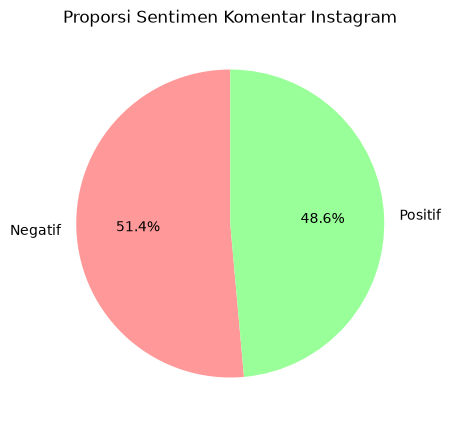

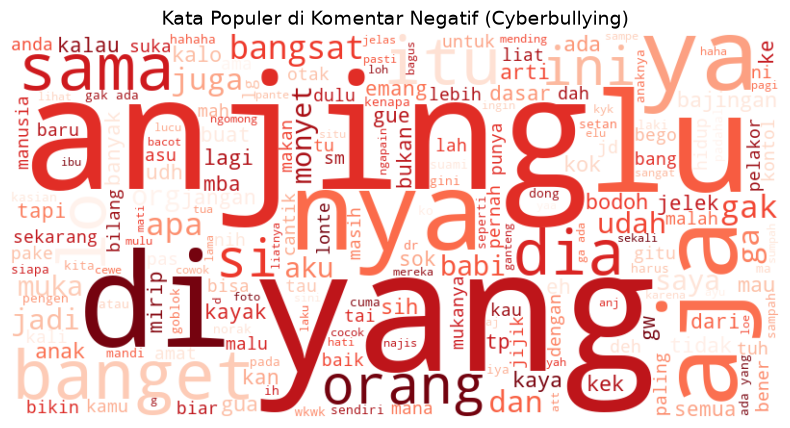

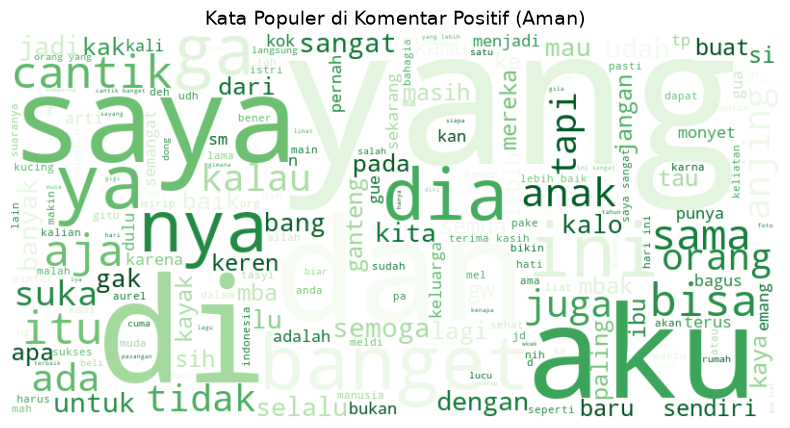

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# 1. Visualisasi Distribusi Kelas (Pie Chart)
plt.figure(figsize=(5,5))
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#99ff99'], startangle=90, labels=['Negatif', 'Positif'])
plt.title('Proporsi Sentimen Komentar Instagram')
plt.ylabel('')
plt.show()

# 2. WordCloud untuk Komentar Negatif (Cyberbullying)
text_negatif = " ".join(df[df['label'] == 'negative']['text_clean'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(text_negatif)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.title('Kata Populer di Komentar Negatif (Cyberbullying)', fontsize=14)
plt.axis('off')
plt.show()

# 3.  WordCloud untuk Komentar Positif (Aman/Baik)
text_positif = " ".join(df[df['label'] == 'positive']['text_clean'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(text_positif)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title('Kata Populer di Komentar Positif (Aman)', fontsize=14)
plt.axis('off')
plt.show()

# Modeling & Evaluasi Eksperimen

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import pickle

X = df['text_clean']
y = df['label']

# Split data (80% Train : 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Arsitektur TF-IDF optimal untuk dataset multi-platform
vectorizer = TfidfVectorizer(ngram_range=(1, 1), max_features=3000, sublinear_tf=True)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# Latih Model Utama: Logistic Regression dengan C=5.0 untuk fleksibilitas pola yang luas
lr_model = LogisticRegression(C=5.0, class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

# Latih Model Pembanding: Naïve Bayes
nb_model = MultinomialNB(alpha=0.2)
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)

print("=====================================================")
print("=== EXPERIMENT 1: LOGISTIC REGRESSION ===")
print("=====================================================")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred_lr) * 100:.2f}%")
print(classification_report(y_test, y_pred_lr))

print("\n=====================================================")
print("===   EXPERIMENT 2: NAÏVE BAYES ====")
print("=====================================================")
print(f"Akurasi Model: {accuracy_score(y_test, y_pred_nb) * 100:.2f}%")
print(classification_report(y_test, y_pred_nb))

# Ekstraksi otomatis model terbaik 
best_model = lr_model if accuracy_score(y_test, y_pred_lr) > accuracy_score(y_test, y_pred_nb) else nb_model

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("\n--> SUCCESS: 'best_model.pkl' & 'vectorizer.pkl' terbaru berhasil diekspor!")

=== EXPERIMENT 1: LOGISTIC REGRESSION ===
Akurasi Model: 75.54%
              precision    recall  f1-score   support

    negative       0.78      0.73      0.76       332
    positive       0.73      0.78      0.76       314

    accuracy                           0.76       646
   macro avg       0.76      0.76      0.76       646
weighted avg       0.76      0.76      0.76       646


===   EXPERIMENT 2: NAÏVE BAYES ====
Akurasi Model: 72.91%
              precision    recall  f1-score   support

    negative       0.72      0.77      0.74       332
    positive       0.74      0.69      0.71       314

    accuracy                           0.73       646
   macro avg       0.73      0.73      0.73       646
weighted avg       0.73      0.73      0.73       646


--> SUCCESS: 'best_model.pkl' & 'vectorizer.pkl' terbaru berhasil diekspor!
